# Generating Points on the Flag Manifold

## Setup

In [36]:
import torch
torch.set_default_dtype(torch.float64)
import numpy as np 
import qmcpy as qp
import agsutil
import time
import pandas as pd
import os
import matplotlib
from matplotlib import pyplot
MPLP = agsutil.mpl_setup()
agsutil.print_data_signatures(MPLP,"MPLP",verbose_indent=0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch device = %s"%DEVICE)
icdf_normal = torch.distributions.Normal(loc=torch.zeros(1,device=DEVICE),scale=torch.ones(1,device=DEVICE)).icdf

MPLP['PW'] = 30
MPLP['FS'] = 30
MPLP['COLORS'] a list of length 10
MPLP['LINESTYLES'] a list of length 10
MPLP['MARKERS'] a list of length 12
torch device = cpu


## Transform and Generators

In [37]:
def tff_qr(u, lam):
    t = lam.size(-1)
    assert u.size(-1)==(t**2)
    assert (0<=u).all()
    assert (u<=1).all()
    u = u.reshape((*u.shape[:-1],t,t))
    v = icdf_normal(u)
    q,r = torch.linalg.qr(v)
    d = torch.diagonal(r,dim1=-2,dim2=-1).sign()
    q = q*d[...,None,:]
    assert torch.allclose(torch.einsum("...ij,...jk->...ik",q,r*d[...,:,None]),v)
    return q
def tff_eig(u, lam):
    t = lam.size(-1) 
    assert u.size(-1)==(t*(t+1)//2+t)
    alpha = icdf_normal(u[...,:t])
    beta = icdf_normal(u[...,t:(-t)])/np.sqrt(2)
    signs = torch.where(u[...,(-t):]>1/2,1.,-1.).to(DEVICE)
    il0,il1 = torch.tril_indices(t,t,offset=-1,device=DEVICE)
    v = torch.eye(t,device=DEVICE)*alpha[...,None]
    v[...,il0,il1] = beta
    v += v.tril(-1).transpose(dim0=-2,dim1=-1)
    assert torch.allclose(v[...,torch.arange(t,device=DEVICE),torch.arange(t,device=DEVICE)],alpha)
    gamma,q = torch.linalg.eigh(v)
    q = q*signs[...,None,:] # this is required because torch.eigh pins the sign to make the largest entry of each eigenvector positive
    assert torch.allclose(torch.einsum("...ij,...kj->...ik",q,q),torch.eye(t,device=DEVICE))
    assert torch.allclose(torch.einsum("...ij,...j,...kj->...ik",q,gamma,q),v)
    return q
def genf_qr_iid_x_equal_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.rand((n,t**2),generator=rng,device=DEVICE)
    q = tff_qr(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = torch.ones(n,device=DEVICE)/n
    return x,w
def genf_qr_iid_x_opt_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.rand((n,t**2),generator=rng,device=DEVICE)
    q = tff_qr(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x,lam,r,c)
    return x,w
def genf_qr_ld_x_equal_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    q = tff_qr(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = torch.ones(n,device=DEVICE)/n
    return x,w
def genf_qr_ld_x_opt_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    q = tff_qr(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x,lam,r,c)
    return x,w
def genf_eig_iid_x_equal_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.rand((n,t*(t+1)//2+t),generator=rng,device=DEVICE)
    q = tff_eig(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = torch.ones(n,device=DEVICE)/n
    return x,w
def genf_eig_iid_x_opt_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.rand((n,t*(t+1)//2+t),generator=rng,device=DEVICE)
    q = tff_eig(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x,lam,r,c)
    return x,w
def genf_eig_ld_x_equal_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t*(t+1)//2+t,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    q = tff_eig(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = torch.ones(n,device=DEVICE)/n
    return x,w
def genf_eig_ld_x_opt_w(n, lam, r, c, seed=None, verbose=None):
    rng = torch.Generator(device=DEVICE) if seed is None else torch.Generator(device=DEVICE).manual_seed(seed)
    t = lam.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t*(t+1)//2+t,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    q = tff_eig(u,lam)
    x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
    w = opt_weights(x,lam,r,c)
    return x,w
# genf_qr_iid_x_equal_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);
# genf_qr_iid_x_opt_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);
# genf_qr_ld_x_equal_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);
# genf_qr_ld_x_opt_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);
# genf_eig_iid_x_equal_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);
# genf_eig_iid_x_opt_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);
# genf_eig_ld_x_equal_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);
# genf_eig_ld_x_opt_w(n=2**3,lam=torch.rand(4,device=DEVICE),r=2,c=1);

## Kernel

In [51]:
def kernel(x, y, lam, r, c):
    jvec = torch.arange(r+1,device=DEVICE)
    rt = jvec[-1]
    logcrj_term = torch.where(rt-jvec==0,torch.zeros_like(rt-jvec),(rt-jvec)*torch.log(c*torch.ones_like(rt)))
    logcomb = agsutil.logcomb(rt,jvec)+logcrj_term+2*jvec*torch.log(lam.sum(-1))-jvec*np.log(lam.size(-1))
    denom = torch.exp(logcomb).sum()
    v = (c+(x*y).sum((-2,-1)))**r/denom 
    return v
def opt_weights(x, lam, r, c):
    kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:],lam,r,c) # (...,n,n)
    b = torch.ones(kmat.size(-1),device=DEVICE) # (...,n,)
    L = torch.linalg.cholesky(kmat,upper=False) # (...,n,n)
    w = torch.cholesky_solve(b[...,None],L,upper=False)[...,0] # (...,n)
    return w
r = 2 
c = 1
lam = torch.arange(1,6)/25
x,wx = genf_qr_iid_x_equal_w(2**3,lam,r,c)
y,wy = genf_qr_iid_x_equal_w(2**10,lam,r,c)
print("x.shape = %s"%str(tuple(x.shape)))
print("wx.shape = %s"%str(tuple(wx.shape)))
print("y.shape = %s"%str(tuple(y.shape)))
print("wy.shape = %s"%str(tuple(wy.shape)))
kvals = kernel(x[:,None,:,:],y[None,:,:,:],lam,r=2,c=1)
print("kvals.shape = %s"%str(tuple(kvals.shape)))
kmeans = (kvals*wy).sum(-1)
print("kmeans.shape = %s"%str(tuple(kmeans.shape)))
print("kmeans = \n%s"%str(kmeans))

x.shape = (8, 5, 5)
wx.shape = (8,)
y.shape = (1024, 5, 5)
wy.shape = (1024,)
kvals.shape = (8, 1024)
kmeans.shape = (8,)
kmeans = 
tensor([1.0004, 1.0001, 1.0000, 1.0001, 1.0003, 1.0002, 1.0000, 1.0001])


## Optimized Points and Weights

In [68]:
def genf_opt_x_w(
        n,
        lam,
        r,
        c,
        seed=None,
        verbose = None, 
        iters = 100,
        eps_kmat = 1e-8,
        verbose_indent = 4,
        ):
    t = lam.size(-1)
    u = torch.from_numpy(qp.DigitalNetB2(t**2,seed=seed,randomize="LMS_DS",order="GRAY")(n)).to(DEVICE)
    q = tff_qr(u,lam)
    theta0 = agsutil.from_unitary(q)
    zerosn = torch.zeros(n,device=DEVICE)
    onesn = torch.ones(n,device=DEVICE)
    eyen = torch.eye(n,device=DEVICE)
    def discrepancy_loss(theta):
        q = agsutil.to_unitary(theta,t)
        x = torch.einsum("...ij,...j,...kj->...ik",q,lam,q)
        kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:],lam,r,c) # (n,n)
        L = torch.linalg.cholesky(kmat+eps_kmat*eyen,upper=False) # (n,n)
        v = torch.linalg.solve_triangular(L,onesn[...,None],upper=False)[...,0]
        # discrep = 1-(v**2).sum(-1)
        return v,x,L
    u,x,L = agsutil.lm_opt(
        f = discrepancy_loss,
        theta0 = theta0,
        ytrue = zerosn,
        iters = iters,
        verbose = verbose,
        verbose_indent = verbose_indent,
        lam0 = 1e-1, 
        alpha0 = 1e-1,
        loss_mult = -1,
        loss_shift = 1,
        # store_data_iters = True,
    )
    # print(data["losses_quantiles"]["50"])
    # print(data["losses_quantiles"]["50"][1:]-data["losses_quantiles"]["50"][:-1])
    w = torch.cholesky_solve(onesn[...,None],L,upper=False)[...,0]
    return x,w
    
genf_opt_x_w(
    n = 2**6, 
    lam=torch.arange(1,4,dtype=float,device=DEVICE)/25,
    r = 3, 
    c = 0,
    seed = 17);

    iter i     | losses_quantiles                                          | lams_quantiles                                            | alphas_quantiles                                          | times     
               | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        | 5         | 25        | 50        | 75        | 90        |           
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    0          | 1.6e-02   | 1.6e-02   | 1.6e-02   | 1.6e-02   | 1.6e-02   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 1.0e-01   | 0.0        
    5          | 1.6e-02   | 1.6e-02   | 1.6e-02   | 1.6e-02   | 1.6e-02   | 3.1e-03   | 3.1e-03   | 3.1e-03   | 3.1e-03   | 3.1e-03   | 3.2e+00   | 3.2e+00   | 3.2e+0

## Convergence on a Test Function

In [76]:
def discrepancy(kernel, x, w, lam, r, c, return_kmat=False):
    assert x.ndim>=2
    assert x.size(-3)==w.size(-1)
    kmat = kernel(x[...,:,None,:,:],x[...,None,:,:,:],lam,r,c) # (...,n,n)
    discrep = torch.einsum("...i,...ij,...j->...",w,kmat,w)-2*w.sum()+1 # (...,)
    if return_kmat:
        return discrep,kmat 
    else:
        return discrep

In [97]:
genf_funcs = [
    [r"QR IID $x$ ~ Equal $w$", genf_qr_iid_x_equal_w], 
    [r"QR LD $x$ ~ Equal $w$", genf_qr_ld_x_equal_w], 
    # [r"QR IID $x$ ~ Opt $w$", genf_qr_iid_x_opt_w], 
    # [r"QR LD $x$ ~ Opt $w$", genf_qr_ld_x_opt_w], 
    [r"Eig IID $x$ ~ Equal $w$", genf_eig_iid_x_equal_w], 
    [r"Eig LD $x$ ~ Equal $w$", genf_eig_ld_x_equal_w], 
    # [r"Eig IID $x$ ~ Opt $w$", genf_eig_iid_x_opt_w], 
    # [r"Eig LD $x$ ~ Opt $w$", genf_eig_ld_x_opt_w], 
    
]
n = 2**torch.arange(2,12)
lam = torch.arange(1,4)/25
r = 5
c = 0
trials = 5
seeds = [i for i in range(trials)]
discreps = torch.empty((len(genf_funcs),len(n),trials))
t0 = time.perf_counter()
for i,(key,genf_func) in enumerate(genf_funcs):
    print(key)
    for j in range(len(n)):
        print("    n = %d"%n[j])
        for t in range(trials):
            x,w = genf_func(n=n[j],lam=lam,r=r,c=c,seed=seeds[t],verbose=False)
            discreps[i,j,t] = float(discrepancy(kernel,x,w,lam,r,c).cpu())
            print("        trial %-10d time %-10.1f discrep %-10.1e"%(t,time.perf_counter()-t0,discreps[i,j,t]))

QR IID $x$ ~ Equal $w$
    n = 4
        trial 0          time 0.0        discrep 5.0e-01   
        trial 1          time 0.0        discrep 1.7e-01   
        trial 2          time 0.0        discrep 3.2e-01   
        trial 3          time 0.0        discrep 2.1e-01   
        trial 4          time 0.0        discrep 2.8e-01   
    n = 8
        trial 0          time 0.0        discrep 1.8e-01   
        trial 1          time 0.0        discrep 2.1e-01   
        trial 2          time 0.0        discrep 3.2e-01   
        trial 3          time 0.0        discrep 1.5e-01   
        trial 4          time 0.0        discrep 2.1e-01   
    n = 16
        trial 0          time 0.0        discrep 1.1e-01   
        trial 1          time 0.0        discrep 1.6e-01   
        trial 2          time 0.0        discrep 1.4e-01   
        trial 3          time 0.0        discrep 8.7e-02   
        trial 4          time 0.0        discrep 1.0e-01   
    n = 32
        trial 0          time 0.0  

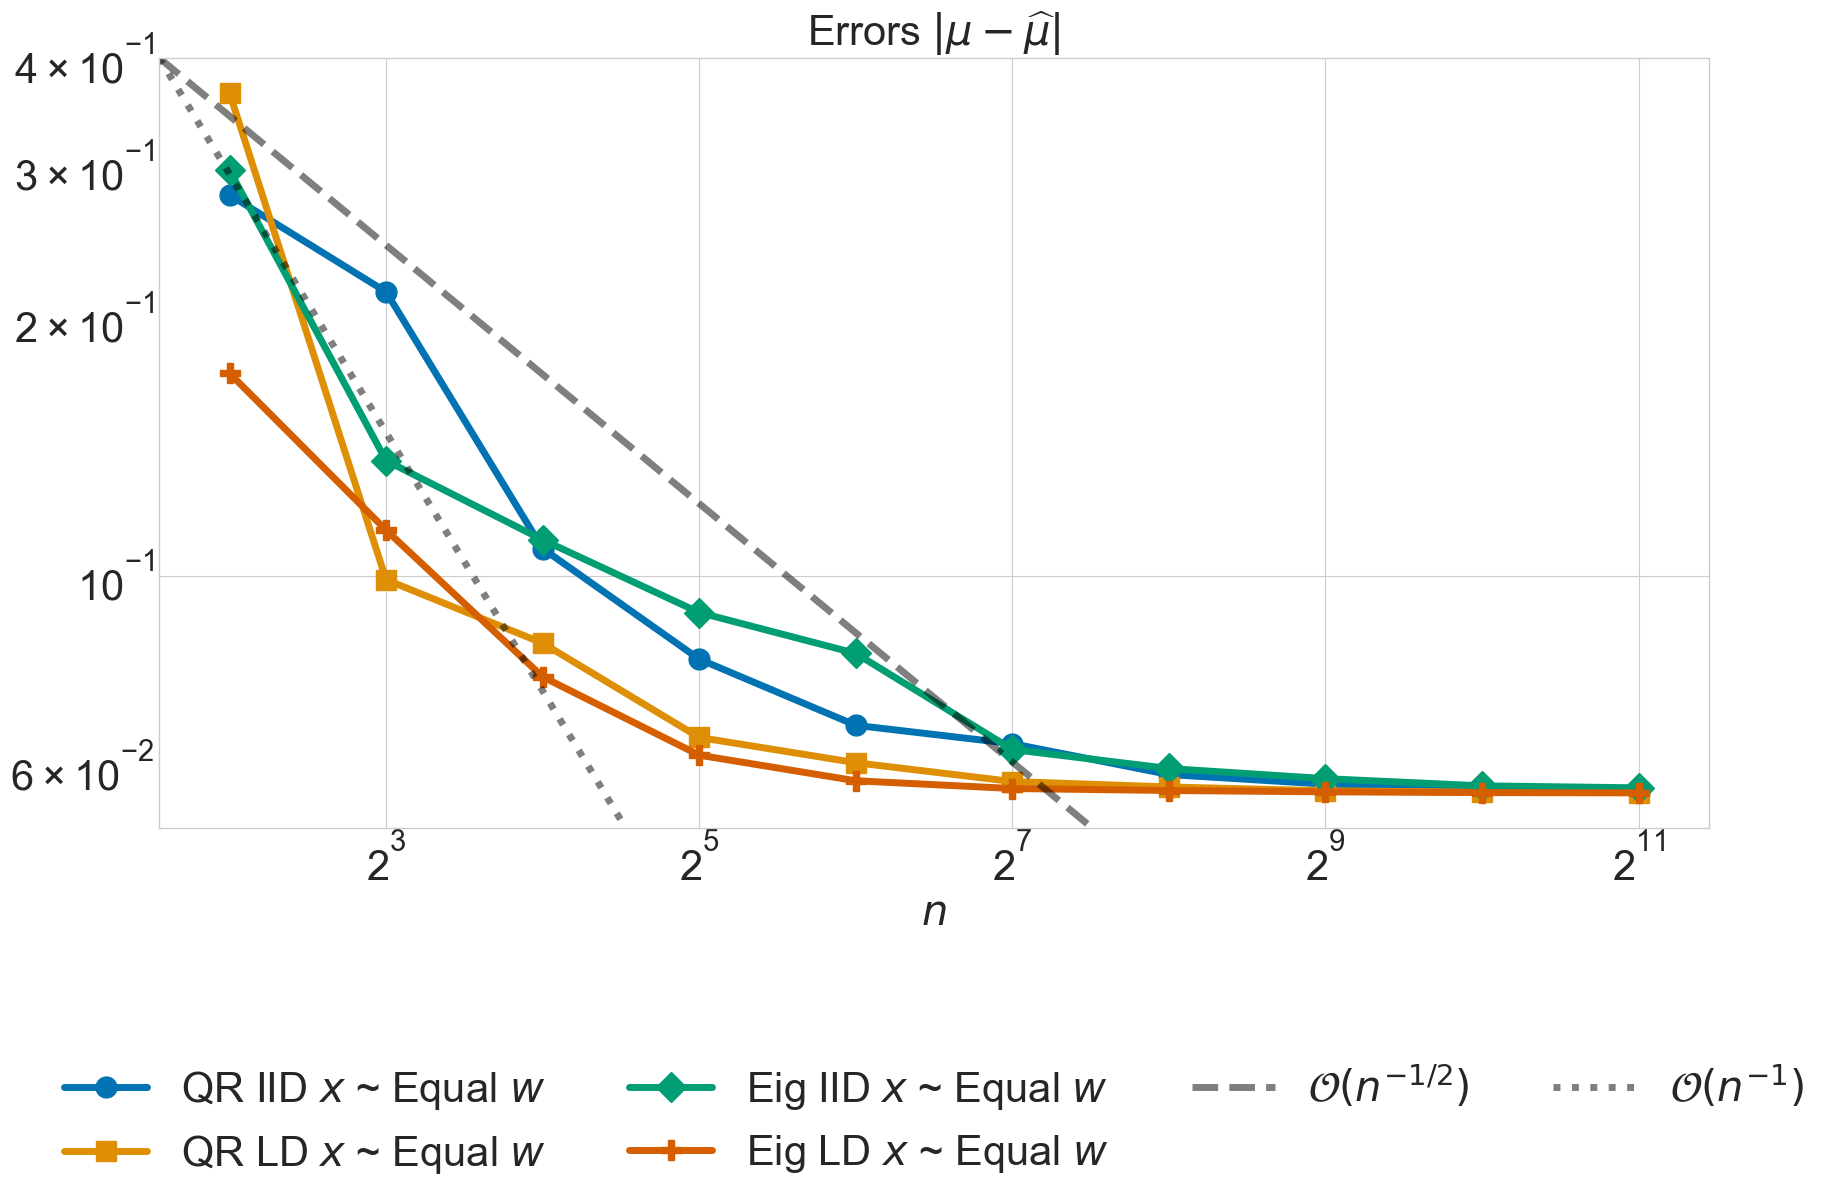

In [98]:
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(MPLP["PW"]/1.5,MPLP["PW"]/2/1.5),sharex=True,sharey=False)
for i,(key,_) in enumerate(genf_funcs):
    ax.plot(n,discreps[i].median(-1).values,color=MPLP["COLORS"][i],marker=MPLP["MARKERS"][i],label=key)
ax.set_yscale("log",base=10)
ax.set_xscale("log",base=2)
xmin,xmax = ax.get_xlim()
ymin,ymax = ax.get_ylim()
ax.set_xlim([xmin,xmax])
ax.set_ylim([ymin,ymax])
ax.axline([xmin,ymax],[2*xmin,2**(-1/2)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(n^{-1/2})$",linestyle="dashed")
ax.axline([xmin,ymax],[2*xmin,2**(-1)*ymax],color="k",alpha=0.5,label=r"$\mathcal{O}(n^{-1})$",linestyle="dotted")
ax.legend(frameon=False,ncols=4,loc="lower center",bbox_to_anchor=(.5,-.5))
ax.set_title(r"Errors $|\mu - \widehat{\mu}|$")
ax.set_xlabel(r"$n$");

In [99]:
discreps_df = pd.DataFrame(discreps.median(-1).values.T,columns=[name for (name,_) in genf_funcs])
discreps_df['n'] = n
discreps_df.set_index('n')
print(r"Discrep")
discreps_df


Discrep


,QR IID $x$ ~ Equal $w$,QR LD $x$ ~ Equal $w$,Eig IID $x$ ~ Equal $w$,Eig LD $x$ ~ Equal $w$,n
0,0.277951,0.365486,0.296919,0.172285,4
1,0.214307,0.099018,0.136282,0.113106,8
2,0.107646,0.083524,0.110202,0.076306,16
3,0.080020,0.064857,0.090678,0.061849,32
4,0.067007,0.060611,0.081263,0.057741,64
5,0.063787,0.057624,0.062796,0.056558,128
6,0.058718,0.056797,0.059677,0.056256,256
7,0.057224,0.056206,0.058072,0.056055,512
8,0.056537,0.056009,0.056963,0.055940,1024
9,0.056189,0.055932,0.056660,0.055906,2048
